In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [25]:
df = pd.read_csv("Amazon_Sale_Report_cleaned.csv")
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,Easy Ship
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship


In [26]:
print(df.isnull().sum())

index                 0
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
promotion-ids         0
B2B                   0
fulfilled-by          0
dtype: int64


In [27]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,128975.000000,128975.000000
mean,64487.000000,0.904431,645.928694,463899.030052
std,37232.019822,0.313354,272.778829,191498.352590
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,459.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,771.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      128975 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            128975 non-null  str    
 15  Amount              128975 non-null  float64


In [29]:
# standardizing
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Standardize Amount column
df["Amount_Standardized"] = scaler.fit_transform(df[["Amount"]])


df[["Amount", "Amount_Standardized"]].head()

,Amount,Amount_Standardized
0,647.62,0.006200
1,406.00,-0.879576
2,329.00,-1.161857
3,753.33,0.393732
4,574.00,-0.263690


In [30]:
#Normalizing
from sklearn.preprocessing import MinMaxScaler

# Create MinMaxScaler object
scaler = MinMaxScaler()

# Normalize Qty column
df["Qty_Normalized"] = scaler.fit_transform(df[["Qty"]])


df[["Qty", "Qty_Normalized"]].head()

,Qty,Qty_Normalized
0,0,0.000000
1,1,0.066667
2,1,0.066667
3,0,0.000000
4,1,0.066667


In [31]:
#to make the data distribution balanced since amount contains some large values

# Apply log transformation
df["Amount_Log"] = np.log1p(df["Amount"])


df[["Amount", "Amount_Log"]].head()

,Amount,Amount_Log
0,647.62,6.474847
1,406.00,6.008813
2,329.00,5.799093
3,753.33,6.625830
4,574.00,6.354370


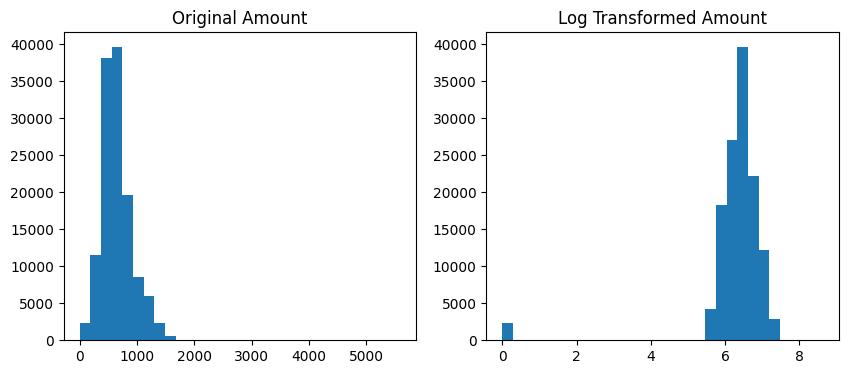

In [32]:
#visula Comparison

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df["Amount"], bins=30)
plt.title("Original Amount")

plt.subplot(1,2,2)
plt.hist(df["Amount_Log"], bins=30)
plt.title("Log Transformed Amount")

plt.show()

In [33]:
df["Date"].head()

0    2022-04-30
1    2022-04-30
2    2022-04-30
3    2022-04-30
4    2022-04-30
Name: Date, dtype: str

In [34]:
#converting date column
df["Date"] = pd.to_datetime(df["Date"])

In [35]:
#Data Transformation
# Extract month from Date
df["Month"] = df["Date"].dt.month


df[["Date", "Month"]].head()

,Date,Month
0,2022-04-30,4
1,2022-04-30,4
2,2022-04-30,4
3,2022-04-30,4
4,2022-04-30,4


In [36]:
#Handling categorical data
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
encoder = LabelEncoder()

# Encode Category
df["Category_Encoded"] = encoder.fit_transform(df["Category"])

# Display first five rows
df[["Category", "Category_Encoded"]].head()

,Category,Category_Encoded
0,Set,5
1,kurta,8
2,kurta,8
3,Western Dress,7
4,Top,6


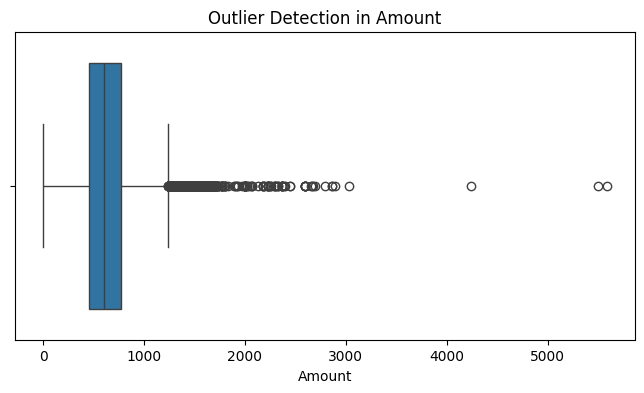

In [24]:
#Outlier Detection
import seaborn as sns

plt.figure(figsize=(8,4))

sns.boxplot(x=df["Amount"])

plt.title("Outlier Detection in Amount")

plt.xlabel("Amount")

plt.show()

In [37]:
df.to_csv("Amazon_Sale_Report_preprocessed.csv", index=False)
print("processed file saved as Amazon_Sale_Report_preprocessed.csv")

processed file saved as Amazon_Sale_Report_preprocessed.csv
